### This notebook contains a detailed description of the dataset along with relevant statistical summaries.

In [1]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from deep_gp.deep_kernel_class import LargeFeatureExtractor, GPRegressionModel
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
features = pd.read_csv('../features.csv')
targets = pd.read_csv('../targets.csv')
data = features.merge(targets[['study_id','case_ISUP']], on='study_id')
X = data.drop(['study_id','patient_id','case_ISUP'], axis=1) # predictors
y = data['case_ISUP'] # target variable

In [3]:
# Count of study_ids per ISUP grade 
counts = data.groupby('case_ISUP')['study_id'].nunique()

print(counts)


case_ISUP
0    589
1    157
2    154
3     69
4     27
5     35
Name: study_id, dtype: int64


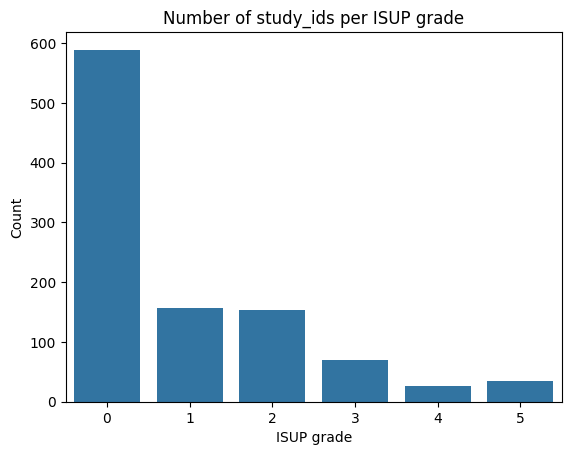

In [4]:
# Plot of number of study_ids per ISUP grade
sns.barplot(x=counts.index, y=counts.values)
plt.title("Number of study_ids per ISUP grade")
plt.xlabel("ISUP grade")
plt.ylabel("Count")
plt.show()

In [5]:
# Correlation of predictors with ISUP grade
corrs = X.corrwith(y).sort_values(key=abs, ascending=False)
print(corrs.head(20))  # top 20 strongest correlations


original_shape_SurfaceVolumeRatio         0.268939
original_shape_LeastAxisLength           -0.254190
original_shape_MinorAxisLength           -0.253180
original_shape_VoxelVolume               -0.246691
original_shape_MeshVolume                -0.246681
original_shape_Maximum2DDiameterRow      -0.244661
original_shape_SurfaceArea               -0.243159
original_shape_Maximum3DDiameter         -0.227730
original_glszm_GrayLevelNonUniformity    -0.217956
original_shape_MajorAxisLength           -0.208944
original_shape_Maximum2DDiameterColumn   -0.207827
original_shape_Maximum2DDiameterSlice    -0.200554
original_glszm_SizeZoneNonUniformity     -0.177351
original_gldm_DependenceNonUniformity    -0.176046
original_ngtdm_Coarseness                 0.169385
original_firstorder_TotalEnergy          -0.164914
original_glrlm_RunLengthNonUniformity    -0.157678
original_glrlm_GrayLevelNonUniformity    -0.133657
original_shape_Sphericity                -0.132356
original_glcm_Imc2             

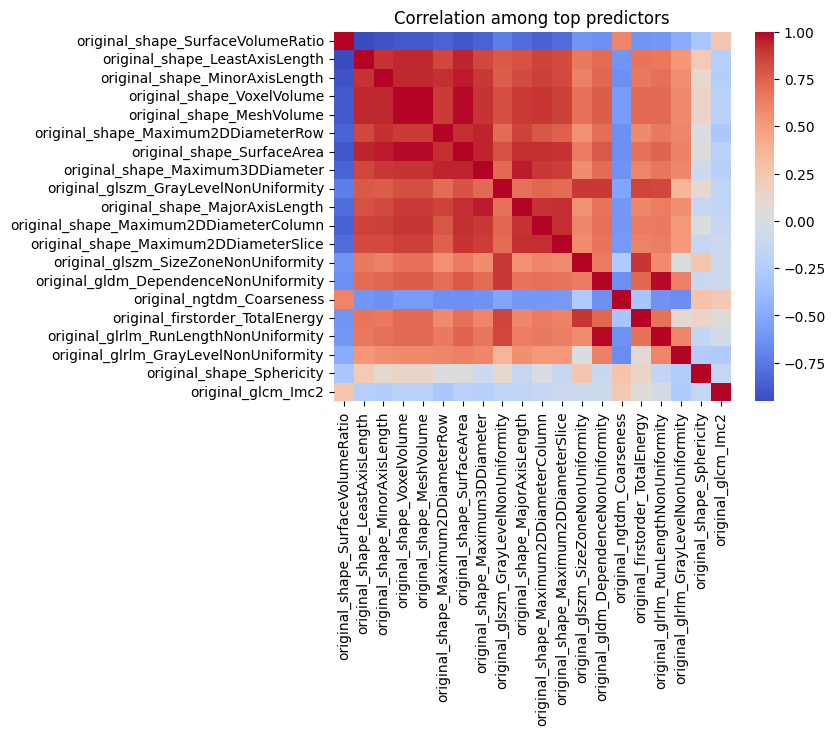

In [6]:
# Heatmap of top 20 predictors
top_predictors = corrs.head(20).index
sns.heatmap(data[top_predictors].corr(), cmap="coolwarm")
plt.title("Correlation among top predictors")
plt.show()

In [7]:
# Statistics
predictor_stats = data.groupby('case_ISUP')[X.columns].agg(['mean','median','std','min','max','quantile'])
predictor_stats 

original_shape_Elongation                                          \
                               mean    median       std       min       max   
case_ISUP                                                                     
0                          0.881161  0.897260  0.076314  0.586025  0.996473   
1                          0.855626  0.874988  0.086619  0.643241  0.992448   
2                          0.852903  0.863867  0.086276  0.399072  0.973635   
3                          0.866995  0.881706  0.075164  0.700211  0.981705   
4                          0.850365  0.837429  0.070938  0.702276  0.978886   
5                          0.881120  0.887666  0.068189  0.663479  0.992628   

                    original_shape_Flatness                                \
           quantile                    mean    median       std       min   
case_ISUP                                                                   
0          0.897260                0.734196  0.742263  0.068964  0.446645   
1          0.874988                0.715446  0.717356  0.077683  0.535111   
2          0.863867                0.700547  0.708756  0.079420  0.245978   
3          0.881706                0.719204  0.721493  0.068653  0.482621   
4          0.837429                0.695699  0.693878  0.058855  0.584046   
5          0.887666                0.730789  0.729553  0.074100  0.604221   

           ... original_ngtdm_Contrast                                \
           ...                     std       min       max  quantile   
case_ISUP  ...                                                         
0          ...                0.023467  0.006753  0.147269  0.042555   
1          ...                0.026388  0.008436  0.175261  0.044229   
2          ...                0.027593  0.008770  0.172040  0.041523   
3          ...                0.027212  0.006263  0.140004  0.043948   
4          ...                0.025198  0.008150  0.099929  0.041257   
5          ...                0.022704  0.012697  0.111431  0.041774   

          original_ngtdm_Strength                                          \
                             mean    median       std       min       max   
case_ISUP                                                                   
0                        0.048647  0.037455  0.046480  0.000662  0.377817   
1                        0.049574  0.041064  0.045490  0.000645  0.236922   
2                        0.055314  0.042493  0.061537  0.000851  0.425337   
3                        0.062530  0.048589  0.052079  0.000775  0.194632   
4                        0.050741  0.047641  0.034536  0.008940  0.148346   
5                        0.070791  0.049034  0.062437  0.004427  0.281843   

                     
           quantile  
case_ISUP            
0          0.037455  
1          0.041064  
2          0.042493  
3          0.048589  
4          0.047641  
5          0.049034  

[6 rows x 642 columns]

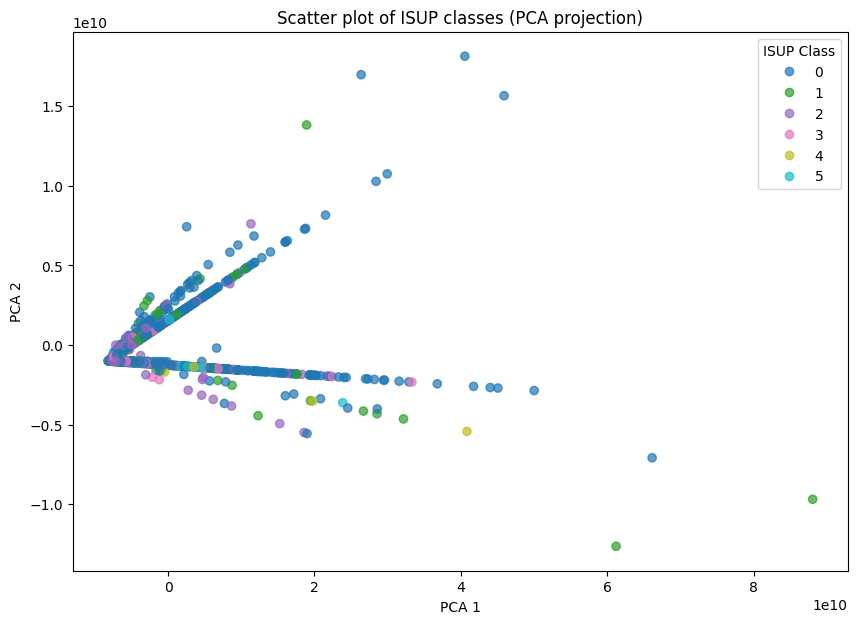

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Scatter plot of ISUP classes (PCA projection)")
plt.legend(*scatter.legend_elements(), title="ISUP Class")
plt.show()


In [9]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

df = X.copy()
df['label'] = y

# Compute target per class
N = len(df)
T = N // 6
print("Target per class:", T)

# STEP 1: Fill minority classes using class 0

idx_class0 = df[df['label'] == 0].index
used = set()

for cls in range(1, 6):
    current = (df['label'] == cls).sum()
    needed = T - current
    print(f"Class {cls} needs {needed}")
    
    if needed <= 0:
        continue
    
    # KNN from class cls to class 0
    cls_idx = df[df['label'] == cls].index
    knn = NearestNeighbors(n_neighbors=1)
    knn.fit(df.loc[cls_idx, X.columns])
    
    distances, indices = knn.kneighbors(df.loc[idx_class0, X.columns])
    sorted_idx = np.argsort(distances.flatten())
    
    selected = []
    for i in sorted_idx:
        idx0 = idx_class0[i]
        if idx0 not in used:
            selected.append(idx0)
            used.add(idx0)
        if len(selected) == needed:
            break
    
    df.loc[selected, 'label'] = cls


# # STEP 2: Reduce class 0 to target size

# idx_class0 = df[df['label'] == 0].index
# extra = len(idx_class0) - T
# print("Class 0 extra samples:", extra)

# if extra > 0:
#     idx_other = df[df['label'] != 0].index
    
#     knn2 = NearestNeighbors(n_neighbors=1)
#     knn2.fit(df.loc[idx_other, X.columns])
    
#     distances, indices = knn2.kneighbors(df.loc[idx_class0, X.columns])
#     sorted_idx = np.argsort(distances.flatten())
    
#     selected = idx_class0[sorted_idx[:extra]]
#     nearest_classes = df.loc[idx_other].iloc[indices[sorted_idx[:extra]].flatten()]['label'].values
    
#     df.loc[selected, 'label'] = nearest_classes

# Final balanced dataset
print("\nFinal balanced counts:")
print(df['label'].value_counts().sort_index())

X_balanced = df.drop(columns=['label'])
y_balanced = df['label']


Target per class: 171
Class 1 needs 14
Class 2 needs 17
Class 3 needs 102
Class 4 needs 144
Class 5 needs 136

Final balanced counts:
label
0    176
1    171
2    171
3    171
4    171
5    171
Name: count, dtype: int64


In [ ]:
print("The number of samples(rows) is", df.shape[0])
print("The number of features (columns) is", df.shape[1])

The number of samples(rows) is 1031
The number of features (columns) is 108


In [10]:
X_balanced = df.drop(columns=['label'])
y_balanced = df['label']


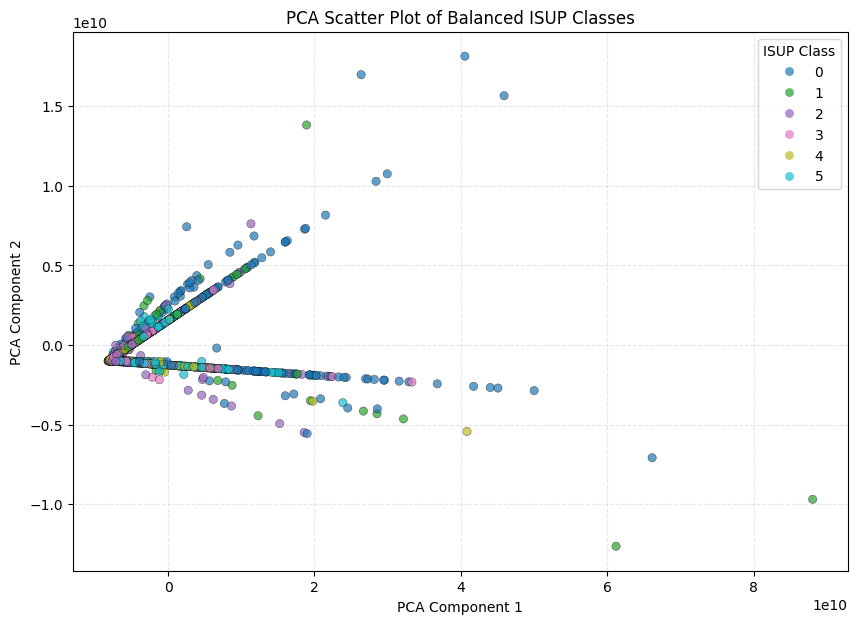

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Run PCA on the balanced dataset
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_balanced)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_balanced,
    cmap='tab10',
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Scatter Plot of Balanced ISUP Classes")
plt.legend(*scatter.legend_elements(), title="ISUP Class")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()
